# Stationary Heat Equation on a Parabolic Waisted Rectangle

Solve the **2D steady-state heat equation** (Laplace equation) on a non-rectangular domain generated with **pymesh**:

$$\nabla^2 u = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0$$

## Domain

A rectangle whose left and right sides are replaced by **parabolic arcs bowing inward** — creating a narrower waist at mid-height.

$$x_{\text{left}}(y)  = \delta \cdot \frac{4y(H-y)}{H^2}, \qquad
  x_{\text{right}}(y) = W - \delta \cdot \frac{4y(H-y)}{H^2}$$

## Boundary conditions

| Boundary | Condition |
|---|---|
| Left arc  | $u = 1$ (hot wall) |
| Right arc | $u = 0$ (cold wall) |
| Top edge  | $\partial u/\partial n = 0$ (insulated) |
| Bottom edge | $\partial u/\partial n = 0$ (insulated) |

In [1]:
import pinns
pinns.use_backend('jax')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import pygmsh

pinns: Using jax backend


## 1. Build the Mesh with pygmsh

We use the `opencascade` kernel.  Left and right sides are B-splines through points sampled from the parabolic formula.  
Physical groups label the four boundary curves so we can extract their nodes reliably after meshing.

In [2]:
# ── Geometry parameters ───────────────────────────────────────────────────
W      = 2.0   # full width
H      = 3.0   # height
indent = 0.5   # maximum inward bow of parabolic arcs (at y = H/2)
h      = 0.08  # target mesh size

def arc_x(y, side):
    """Parabolic arc: bow = indent * 4*y*(H-y)/H^2"""
    bow = indent * 4 * y * (H - y) / H**2
    return bow if side == "left" else W - bow

N_arc = 20   # intermediate control points per curved side

# ── Build mesh with pygmsh (OpenCASCADE kernel) ────────────────────────────
with pygmsh.occ.Geometry() as geom:
    geom.characteristic_length_min = h
    geom.characteristic_length_max = h

    # Corner points
    bl = geom.add_point([0.0, 0.0, 0.0])
    br = geom.add_point([W,   0.0, 0.0])
    tr = geom.add_point([W,   H,   0.0])
    tl = geom.add_point([0.0, H,   0.0])

    # Intermediate control points along the parabolic arcs (excluding corners)
    y_mid = np.linspace(0, H, N_arc + 2)[1:-1]
    left_pts  = [geom.add_point([arc_x(y, "left"),  y, 0.0]) for y in y_mid]
    right_pts = [geom.add_point([arc_x(y, "right"), y, 0.0]) for y in y_mid]

    # Curves
    c_bottom = geom.add_line(bl, br)
    c_right  = geom.add_bspline([br] + right_pts + [tr])
    c_top    = geom.add_line(tr, tl)
    c_left   = geom.add_bspline([tl] + left_pts[::-1] + [bl])

    # Surface
    loop    = geom.add_curve_loop([c_bottom, c_right, c_top, c_left])
    surface = geom.add_plane_surface(loop)

    # Physical groups — used to identify boundary edges afterward
    geom.add_physical(c_bottom, "bottom")
    geom.add_physical(c_right,  "right")
    geom.add_physical(c_top,    "top")
    geom.add_physical(c_left,   "left")
    geom.add_physical(surface,  "interior")

    mesh = geom.generate_mesh(dim=2, verbose=False)

# ── Extract vertices and faces ─────────────────────────────────────────────
verts = mesh.points[:, :2]          # (n_verts, 2)  — drop z column
faces = mesh.cells_dict["triangle"] # (n_faces, 3)

# ── Debug: show what meshio actually stored ────────────────────────────────
print("cell_sets_dict keys :", list(mesh.cell_sets_dict.keys()))
print("cells types         :", [cb.type for cb in mesh.cells])

# ── Extract boundary edge connectivity (v0, v1) pairs ─────────────────────
def boundary_edges(mesh, name):
    """
    Return (n_edges, 2) vertex-index pairs for a named physical group.
    Gmsh stores boundary curves as 'line' cells — each row is one edge.
    """
    if name in mesh.cell_sets_dict:
        for cell_type, block_indices in mesh.cell_sets_dict[name].items():
            if "line" in cell_type:
                cells_of_type = mesh.cells_dict.get(cell_type)
                if cells_of_type is not None:
                    return cells_of_type[block_indices]  # (n_edges, 2)
    if hasattr(mesh, "field_data") and name in mesh.field_data:
        tag = mesh.field_data[name][0]
        for cb, tag_arr in zip(mesh.cells, mesh.cell_data["gmsh:physical"]):
            if cb.type == "line":
                rows = cb.data[tag_arr == tag]
                if len(rows):
                    return rows
    raise KeyError(f"Physical group '{name}' not found.")

# Edge connectivity per boundary (used for BC setup)
edges_left   = boundary_edges(mesh, "left")
edges_right  = boundary_edges(mesh, "right")
edges_top    = boundary_edges(mesh, "top")
edges_bottom = boundary_edges(mesh, "bottom")

print(f"\nMesh: {len(verts)} vertices, {len(faces)} triangles")
print(f"Boundary edges — left: {len(edges_left)}, right: {len(edges_right)}, "
      f"top: {len(edges_top)}, bottom: {len(edges_bottom)}")


cell_sets_dict keys : ['bottom', 'right', 'top', 'left', 'interior']
cells types         : ['line', 'triangle', 'vertex']

Mesh: 875 vertices, 1536 triangles
Boundary edges — left: 41, right: 41, top: 25, bottom: 25


### Visualize the mesh and boundary node selection

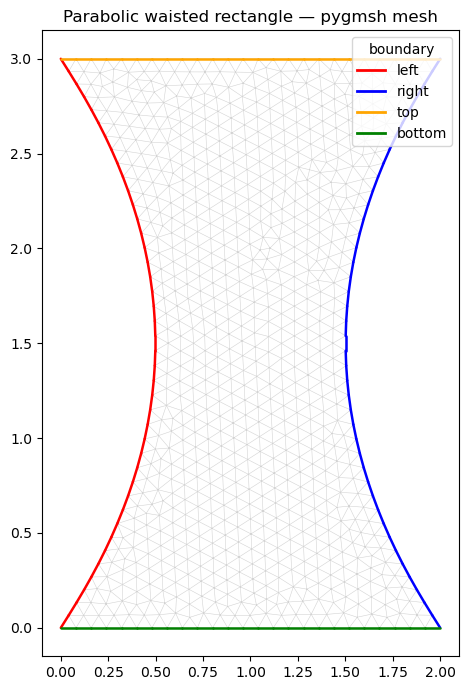

In [3]:
fig, ax = plt.subplots(figsize=(5, 7))
tri_plot = mtri.Triangulation(verts[:, 0], verts[:, 1], faces)
ax.triplot(tri_plot, color="lightgray", lw=0.4)

colors = {"left": "red", "right": "blue", "top": "orange", "bottom": "green"}
for bname, bedges in [("left",   edges_left),  ("right", edges_right),
                      ("top",    edges_top),   ("bottom", edges_bottom)]:
    color = colors[bname]
    for v0, v1 in bedges:
        ax.plot(verts[[v0, v1], 0], verts[[v0, v1], 1],
                color=color, lw=1.8, solid_capstyle="round")
    # Single legend entry per boundary
    ax.plot([], [], color=color, lw=2, label=bname)

ax.set_aspect("equal")
ax.legend(title="boundary", loc="upper right")
ax.set_title("Parabolic waisted rectangle — pygmsh mesh")
plt.tight_layout()
plt.show()


## 2. Define the Domain and Boundary Conditions

Pass the pygmsh/meshio mesh directly to `DomainMesh` — it auto-detects `.points` / `.cells_dict`.  
Boundary nodes are passed as **index arrays** extracted from the physical groups.

In [4]:
domain = pinns.DomainMesh(mesh)   # purely spatial — no t_interval

# ── Boundary conditions ───────────────────────────────────────────────────
# select accepts (n, 2) vertex-pair arrays directly — no index conversion needed.
domain.add_dirichlet(select=edges_top,    value=1.0, component=0, name="hot")
domain.add_dirichlet(select=edges_bottom, value=0.0, component=0, name="cold")
domain.add_neumann(select=edges_left,   value=0.0, component=0, name="insulated_left")
domain.add_neumann(select=edges_right,  value=0.0, component=0, name="insulated_right")

for bc in domain.boundary_conditions:
    n_edges = len(bc.edges) if bc.edges is not None else 0
    print(f"  {bc.name:22s} {n_edges} edges  ({len(bc.node_positions)} unique nodes)")
print(domain)


  hot                    25 edges  (26 unique nodes)
  cold                   25 edges  (26 unique nodes)
  insulated_left         41 edges  (42 unique nodes)
  insulated_right        41 edges  (42 unique nodes)
DomainMesh(2D, n_nodes=875, n_conditions=4)


## 3. Define the PDE

Steady-state heat equation (Laplace):  $\;\nabla^2 u = u_{xx} + u_{yy} = 0$

In [5]:
def laplace(X, V, params, derivative=None):
    """Laplace residual: u_xx + u_yy = 0.  X: [x, y],  V: [u]"""
    if derivative is None:
        derivative = pinns.derivative
    u_xx = derivative(V, X, component=0, order=(0, 0))
    u_yy = derivative(V, X, component=0, order=(1, 1))
    return u_xx + u_yy

## 4. Problem, Network, and Trainer

In [6]:
problem = pinns.Problem(
    domain=domain,
    pde_fn=laplace,
    input_names=["x", "y"],
    output_names=["u"],
    lagrange_multipliers=["top", "bottom", "left", "right"],
    output_range=(0, 1),
)

network = pinns.FNN(
    layer_sizes=[2, 64, 64, 64, 1],
    activation="tanh",
    normalize_input=True,
    unnormalize_output=True,
)

## 5. Train

Interior points: exact barycentric triangle sampling (area-weighted, zero rejection).  
BC points: uniform draw from physical-group node arrays.

Problem(domain=DomainMesh(2D, n_nodes=875, n_conditions=4), n_dims=2, n_outputs=1, n_boundary_conditions=4, params=[])


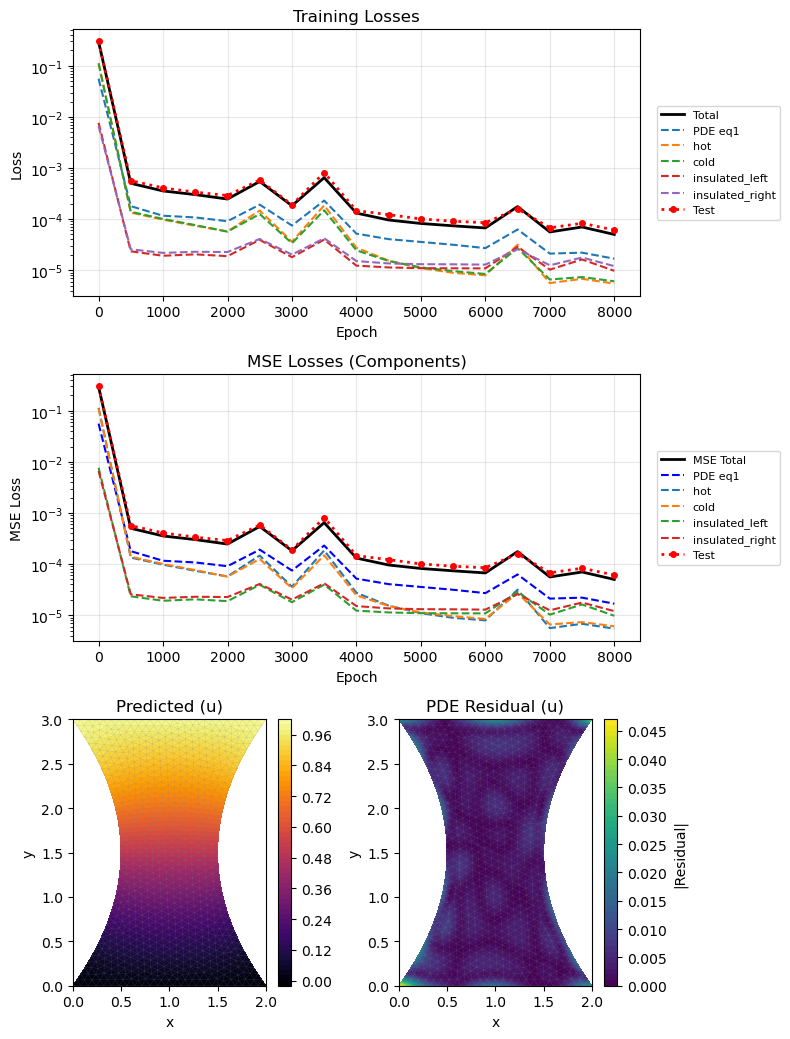

Starting Trainer (JAX, Lagrangian mode) for 8000 epochs...
Epoch 0/8000 | MSE Loss: 2.95e-01 | PDE: 5.61e-02 | BCs: [hot: 1.14e-01, cold: 1.11e-01, insulated_left: 7.66e-03, insulated_right: 6.63e-03]
Epoch 500/8000 | AL Loss: 5.02e-04 | MSE Loss: 5.02e-04 | PDE: 1.79e-04 | BCs: [hot: 1.34e-04, cold: 1.39e-04, insulated_left: 2.34e-05, insulated_right: 2.57e-05] | Time: 9.6s
Epoch 1000/8000 | AL Loss: 3.56e-04 | MSE Loss: 3.56e-04 | PDE: 1.16e-04 | BCs: [hot: 9.76e-05, cold: 1.01e-04, insulated_left: 1.92e-05, insulated_right: 2.18e-05] | Time: 10.5s
Epoch 1500/8000 | AL Loss: 3.02e-04 | MSE Loss: 3.02e-04 | PDE: 1.08e-04 | BCs: [hot: 7.40e-05, cold: 7.64e-05, insulated_left: 2.04e-05, insulated_right: 2.30e-05] | Time: 11.2s
Epoch 2000/8000 | AL Loss: 2.47e-04 | MSE Loss: 2.47e-04 | PDE: 9.10e-05 | BCs: [hot: 5.74e-05, cold: 5.68e-05, insulated_left: 1.89e-05, insulated_right: 2.27e-05] | Time: 11.9s
Epoch 2500/8000 | AL Loss: 5.45e-04 | MSE Loss: 5.45e-04 | PDE: 1.92e-04 | BCs: [hot:

In [7]:
trainer = pinns.Trainer(problem, network)
print(problem)

trainer.compile(
    train_samples={
        "pde":                5000,
        "hot":                300,
        "cold":               300,
        "insulated_left":     150,
        "insulated_right":    150,
    },
    test_samples={
        "pde":                500,
        "hot":                50,
        "cold":               50,
        "insulated_left":     30,
        "insulated_right":    30,
    },
    weights={
        "pde":                1.0,
        "hot":                1.0,
        "cold":               1.0,
        "insulated_left":     1.0,
        "insulated_right":    1.0,
    },
    optimizer="adam",
    learning_rate=1e-3,
    epochs=8000,
    print_each=500,
    show_plots=True,
)

trainer.train()

## 5b. Fine-tune with L-BFGS

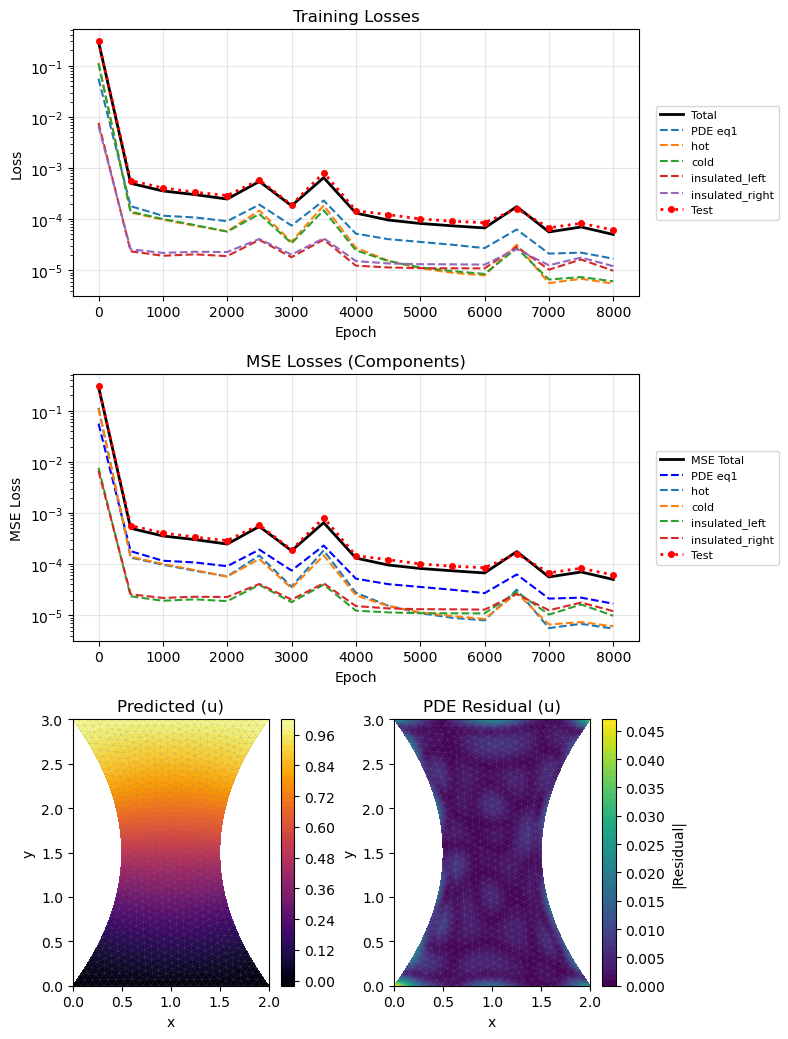

Starting Trainer (JAX, Lagrangian mode) for 300 epochs...
Epoch 0/300 | MSE Loss: 4.98e-05 | PDE: 1.80e-05 | BCs: [hot: 5.05e-06, cold: 5.80e-06, insulated_left: 1.23e-05, insulated_right: 8.69e-06]


AttributeError: 'NoneType' object has no attribute 'update'

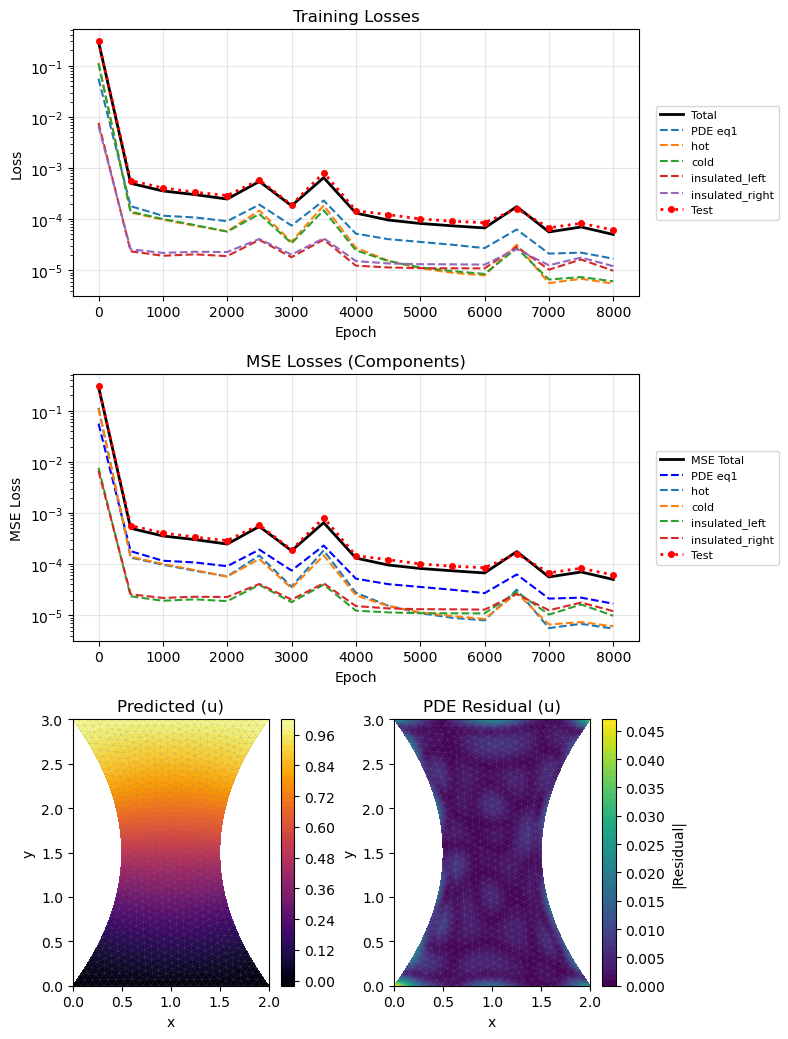

In [8]:
trainer.compile(
    optimizer="lbfgs",
    epochs=300,
    print_each=50,
    show_plots=True,
)

trainer.train()

## 6. Visualize the Solution

Plot the predicted temperature field $u(x,y)$ on the mesh triangulation.

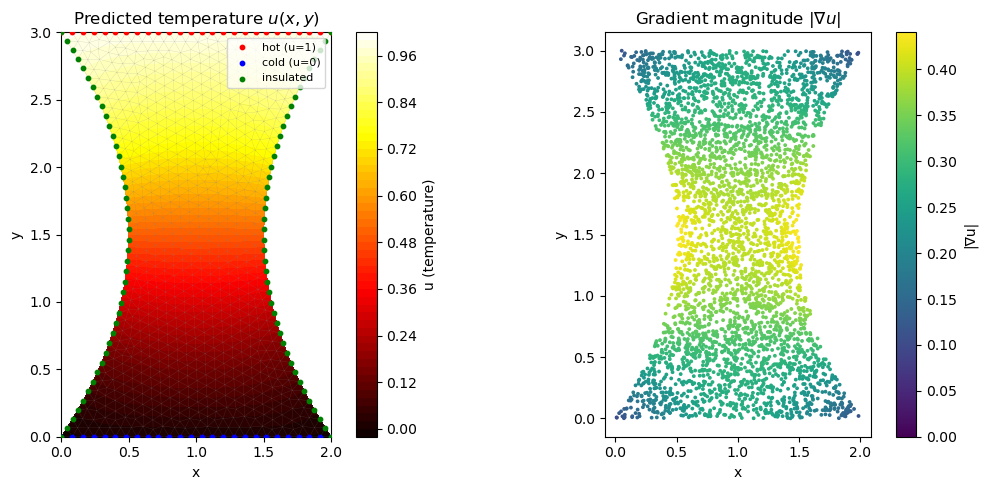

In [ ]:
import jax.numpy as jnp

# Evaluate network at all mesh vertices
params_dict = trainer._build_params()
x_query = jnp.array(verts, dtype=jnp.float32)
u_pred = trainer.network.forward(x_query, params_dict)
u_vals = np.asarray(u_pred[:, 0])  # (n_verts,)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

tri_plot = mtri.Triangulation(verts[:, 0], verts[:, 1], faces)

# Solution field
tcf = axes[0].tricontourf(tri_plot, u_vals, levels=50, cmap="hot")
axes[0].triplot(tri_plot, color="gray", lw=0.2, alpha=0.4)
fig.colorbar(tcf, ax=axes[0], label="u (temperature)")
axes[0].set_title("Predicted temperature $u(x,y)$")
axes[0].set_aspect("equal")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

# Highlight boundary conditions
for bc, color, label in [
    (domain.boundary_conditions[0], "red",   "hot (u=1)"),
    (domain.boundary_conditions[1], "blue",  "cold (u=0)"),
    (domain.boundary_conditions[2], "green", "insulated"),
    (domain.boundary_conditions[3], "green", "_nolegend_"),
]:
    pts = bc.node_positions
    axes[0].scatter(pts[:, 0], pts[:, 1], s=10, c=color, label=label, zorder=4)
axes[0].legend(loc="upper right", fontsize=8)

# Gradient magnitude |∇u|  (finite-difference on mesh vertices is approximate; use training samples)
n_eval = 4000
rng    = np.random.default_rng(0)
pts_r  = domain._sample_interior_spatial(n_eval, rng)
x_r    = jnp.array(pts_r, dtype=jnp.float32)
from jax import grad, vmap
import jax

def u_scalar(xy):
    v = trainer.network.forward(xy[None], params_dict)
    return v[0, 0]

grad_u  = vmap(grad(u_scalar))(x_r)
grad_nm = np.linalg.norm(np.asarray(grad_u), axis=1)

sc = axes[1].scatter(pts_r[:, 0], pts_r[:, 1],
                     c=grad_nm, s=3, cmap="viridis", vmin=0)
fig.colorbar(sc, ax=axes[1], label="|∇u|")
axes[1].set_title("Gradient magnitude $|\\nabla u|$")
axes[1].set_aspect("equal")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()